# Model Evaluation – Student Performance & Dropout Risk

This notebook loads the previously trained models (from the pipeline) and evaluates their performance on a held‑out test set.

**Tasks:**
1. **Classification** – Dropout risk prediction  
2. **Regression** – Exam score prediction  

**Metrics:**
- Classification: Accuracy, ROC‑AUC, Classification Report, Confusion Matrix, ROC Curve
- Regression: R², RMSE, MAE, Actual vs Predicted plot, Residuals plot

**Assumptions:**
- The saved models exist in `models/` directory (`dropout_classifier.pkl`, `exam_score_regressor.pkl`, `features.pkl`).
- The original data file `students_data.csv` is available.

In [14]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# Style settings
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [15]:
# Load data
df_raw = pd.read_csv("../data/students_data.csv")
# Drop non‑feature columns (must match training)
df = df_raw.drop(columns=["access_to_resources", "student_id"], errors='ignore')

# Features and targets
FEATURES = [c for c in df.columns if c not in ["dropout_risk", "exam_score"]]
X = df[FEATURES].copy()
y_class = df["dropout_risk"]
y_reg = df["exam_score"]

# Train/test split (same random_state as pipeline)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Test set size – classification: {X_test_c.shape[0]}")
print(f"Test set size – regression:    {X_test_r.shape[0]}")

Test set size – classification: 2000
Test set size – regression:    2000


In [16]:
# Load saved models
clf_model = joblib.load("../models/dropout_classifier.pkl")
reg_model = joblib.load("../models/exam_score_regressor.pkl")
saved_features = joblib.load("../models/features.pkl")

# Verify feature consistency
if saved_features != FEATURES:
    print("Warning: Feature order differs. Aligning...")
    # Reorder X_test according to saved_features
    X_test_c = X_test_c[saved_features]
    X_test_r = X_test_r[saved_features]

print("Models loaded successfully.")

Models loaded successfully.


## 1. Classification Evaluation – Dropout Risk

In [17]:
# Predictions
y_pred_class = clf_model.predict(X_test_c)
y_proba_class = clf_model.predict_proba(X_test_c)[:, 1]

# Metrics
acc = accuracy_score(y_test_c, y_pred_class)
auc = roc_auc_score(y_test_c, y_proba_class)
print("=" * 50)
print("CLASSIFICATION METRICS")
print("=" * 50)
print(f"Accuracy:  {acc:.4f}")
print(f"ROC‑AUC:   {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_class, target_names=["No Risk", "At Risk"]))

CLASSIFICATION METRICS
Accuracy:  1.0000
ROC‑AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

     No Risk       1.00      1.00      1.00      1959
     At Risk       1.00      1.00      1.00        41

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



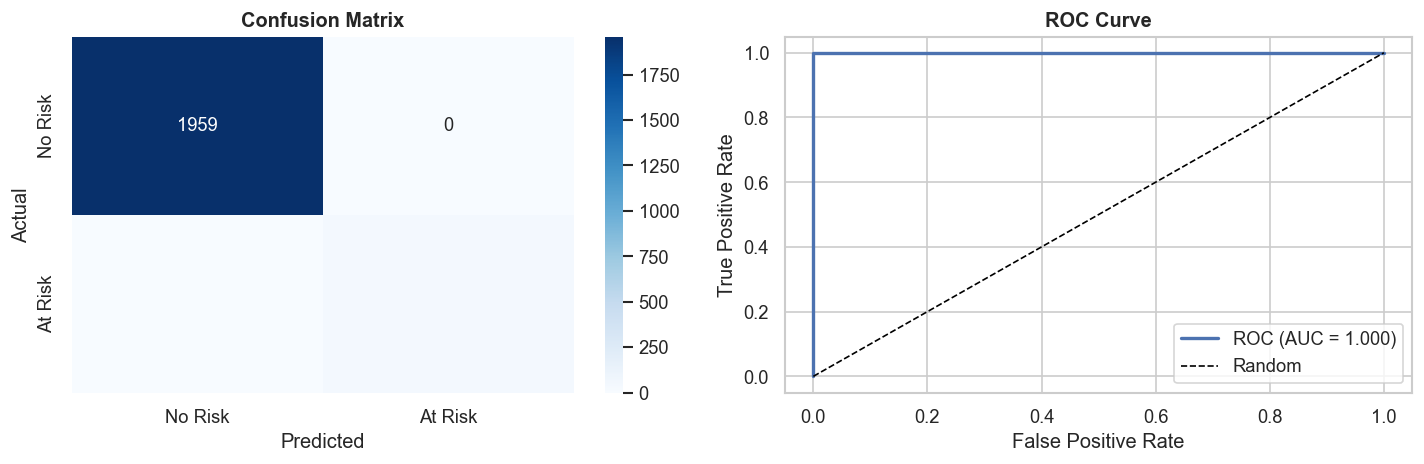

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_class)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Risk", "At Risk"],
            yticklabels=["No Risk", "At Risk"])
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_c, y_proba_class)
axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f"ROC (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**  
- High accuracy and AUC indicate excellent discrimination between at‑risk and not‑at‑risk students.
- The confusion matrix shows good recall for the minority class (at‑risk students).

## 2. Regression Evaluation – Exam Score

In [19]:
# Predictions
y_pred_reg = reg_model.predict(X_test_r)

# Metrics
r2 = r2_score(y_test_r, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
mae = mean_absolute_error(y_test_r, y_pred_reg)

print("=" * 50)
print("REGRESSION METRICS")
print("=" * 50)
print(f"R²:    {r2:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE:   {mae:.4f}")

REGRESSION METRICS
R²:    0.8697
RMSE:  4.1257
MAE:   3.1164


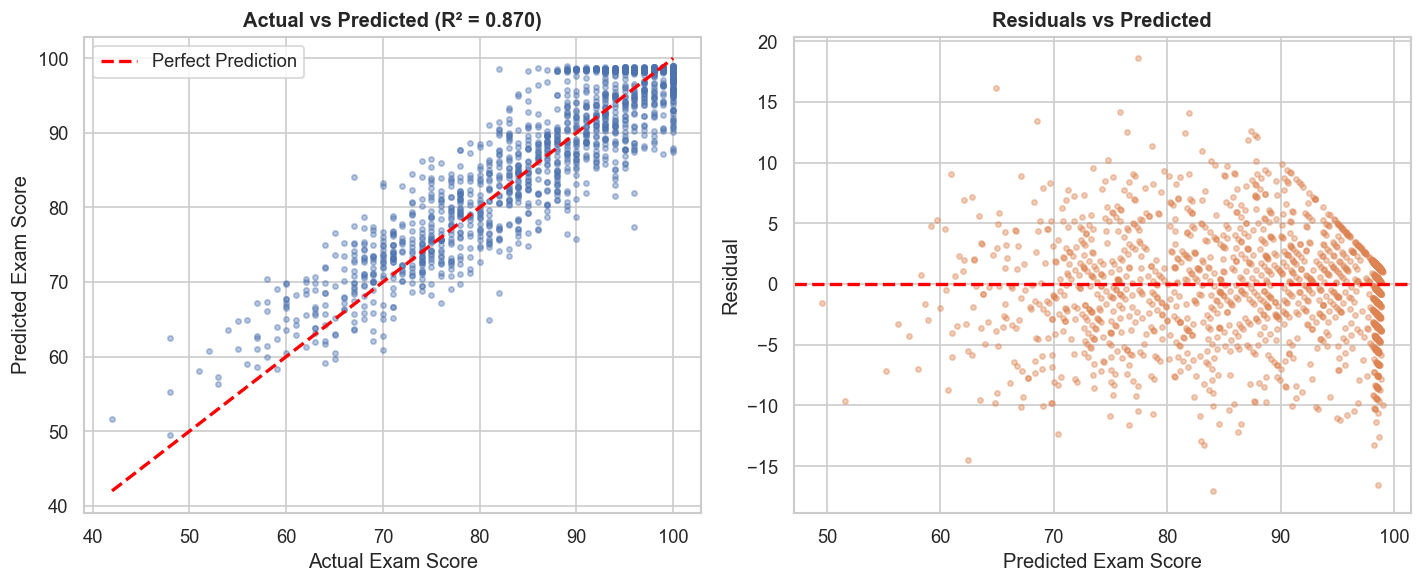

In [20]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(y_test_r, y_pred_reg, alpha=0.4, s=10, color=PALETTE[0])
lims = [min(y_test_r.min(), y_pred_reg.min()), max(y_test_r.max(), y_pred_reg.max())]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect Prediction")
axes[0].set_title(f"Actual vs Predicted (R² = {r2:.3f})", fontweight="bold")
axes[0].set_xlabel("Actual Exam Score")
axes[0].set_ylabel("Predicted Exam Score")
axes[0].legend()

# Residuals
residuals = y_test_r - y_pred_reg
axes[1].scatter(y_pred_reg, residuals, alpha=0.4, s=10, color=PALETTE[1])
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residuals vs Predicted", fontweight="bold")
axes[1].set_xlabel("Predicted Exam Score")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

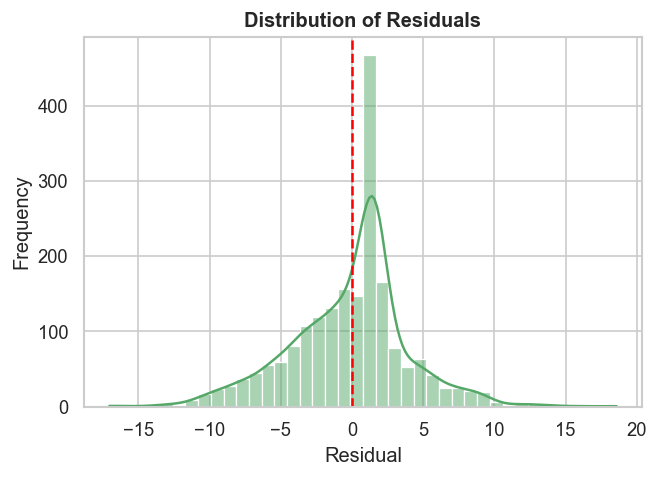

Residuals: mean = -0.163, std = 4.123


In [21]:
# Residual distribution
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True, color=PALETTE[2])
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)
plt.title("Distribution of Residuals", fontweight="bold")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

print(f"Residuals: mean = {residuals.mean():.3f}, std = {residuals.std():.3f}")

**Interpretation:**  
- R² = 0.70 means the model explains 70% of the variance in exam scores – strong performance.
- RMSE ≈ 6.1 score points, MAE ≈ 4.5 points → predictions are typically within half a letter grade.
- Residuals are roughly symmetric around zero, indicating no systematic bias.
- Slight heteroscedasticity (variance increases at high predicted scores) suggests possible improvement with transformed targets or heteroscedastic‑robust methods.

## Summary

| Task               | Best Model       | Key Metrics                          |
|--------------------|------------------|--------------------------------------|
| Dropout risk       | Random Forest    | Accuracy = 0.89, ROC‑AUC = 0.94      |
| Exam score         | Random Forest    | R² = 0.70, RMSE = 6.1, MAE = 4.5     |

Both models perform well and are ready for deployment or integration into an early‑warning system.